In [72]:
"""
Problem:
------------------
Building a machine learning model to predict whether a patient 
has diabetes or not, based on health features.

Dataset:
--------
Pima Indians Diabetes Dataset (diabetes.csv)

Columns:
- Pregnancies: Number of times pregnant
- Glucose: Plasma glucose concentration
- BloodPressure: Diastolic blood pressure (mm Hg)
- SkinThickness: Triceps skinfold thickness (mm)
- Insulin: 2-Hour serum insulin (mu U/ml)
- BMI: Body mass index (weight in kg/(height in m)^2)
- DiabetesPedigreeFunction: Diabetes likelihood based on family history
- Age: Age of the patient
- Outcome: Target variable (1 = Diabetic, 0 = Non-Diabetic)
"""

'\nProblem:\n------------------\nBuilding a machine learning model to predict whether a patient \nhas diabetes or not, based on health features.\n\nDataset:\n--------\nPima Indians Diabetes Dataset (diabetes.csv)\n\nColumns:\n- Pregnancies: Number of times pregnant\n- Glucose: Plasma glucose concentration\n- BloodPressure: Diastolic blood pressure (mm Hg)\n- SkinThickness: Triceps skinfold thickness (mm)\n- Insulin: 2-Hour serum insulin (mu U/ml)\n- BMI: Body mass index (weight in kg/(height in m)^2)\n- DiabetesPedigreeFunction: Diabetes likelihood based on family history\n- Age: Age of the patient\n- Outcome: Target variable (1 = Diabetic, 0 = Non-Diabetic)\n'

In [73]:
#Basic Inspection
import pandas as pd

df = pd.read_csv('diabetes.csv')

print("Dataset Shape: ", df.shape)
print(df.head())
print(df.describe())
print('\n Missing values per column \n',df.isnull().sum())

Dataset Shape:  (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807     

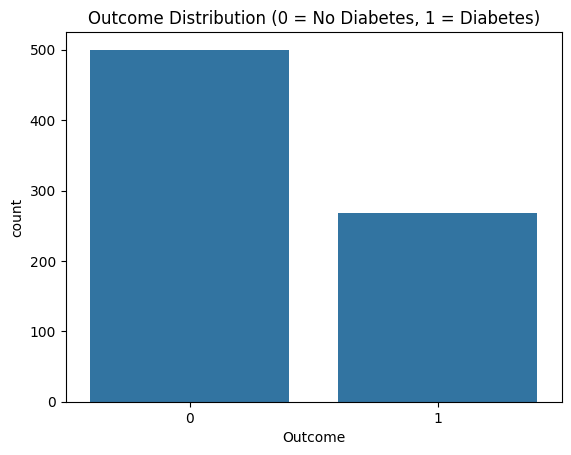

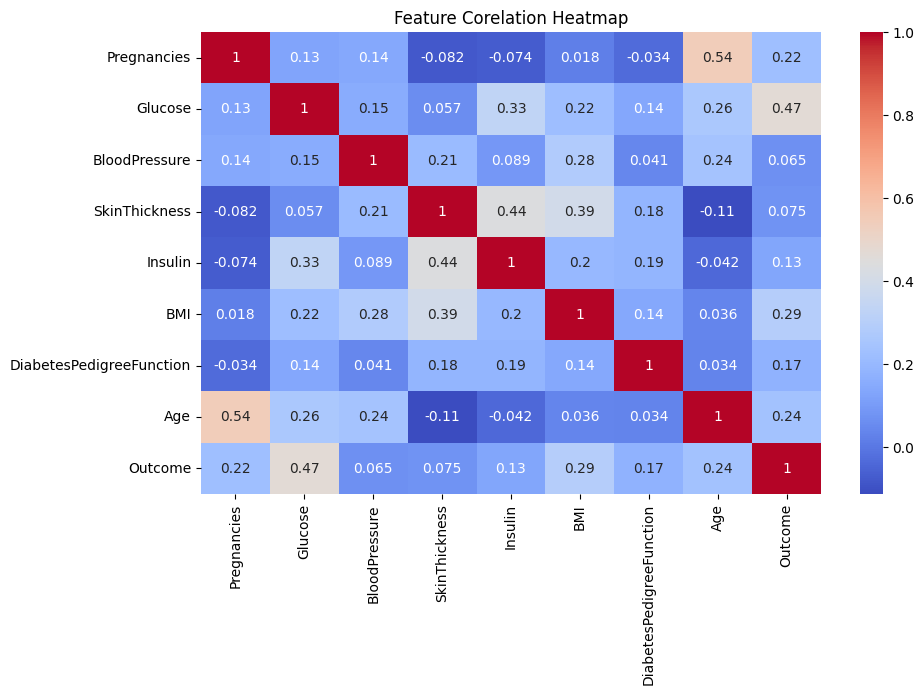

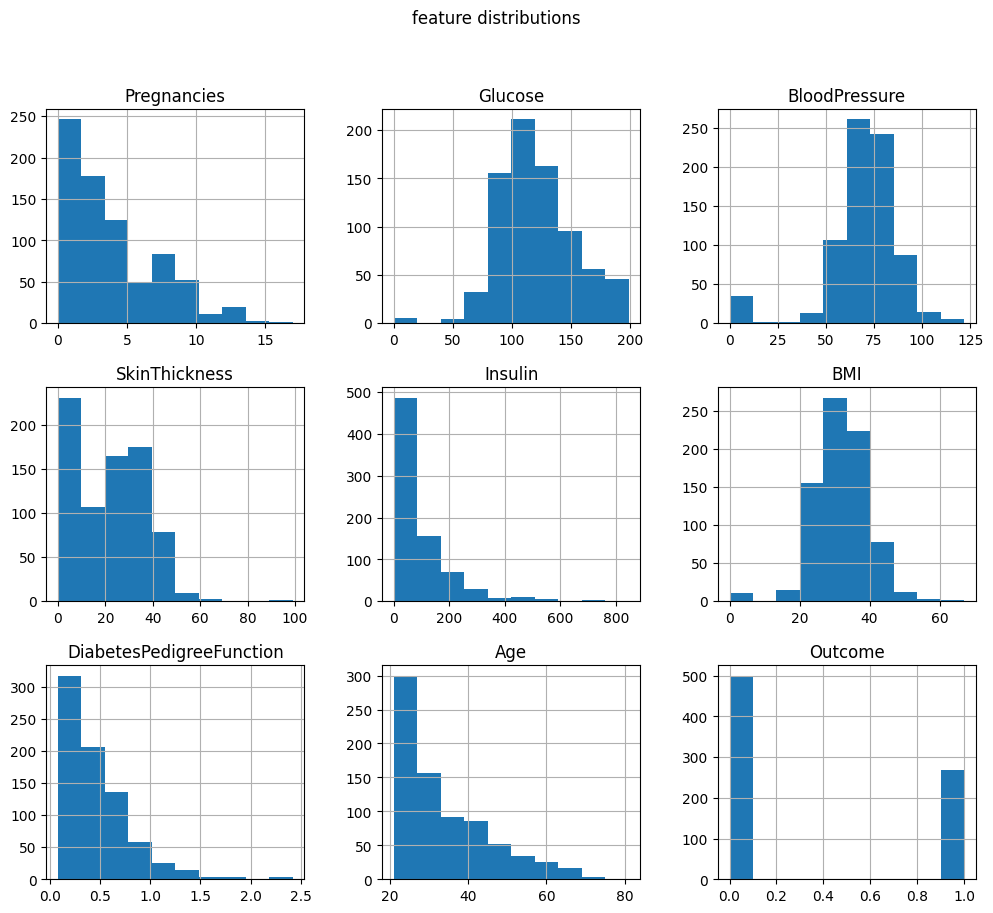

In [74]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Outcome',data=df)
plt.title('Outcome Distribution (0 = No Diabetes, 1 = Diabetes)')

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap = 'coolwarm')
plt.title('Feature Corelation Heatmap')
plt.show()

df.hist(figsize=(12,10))
plt.suptitle('feature distributions')
plt.show()

In [75]:
# Preprocessing and Feature Engineering
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

zero_features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_features:
    df[col] = df[col].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Preprocessing complete. Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Preprocessing complete. Shapes:
X_train: (614, 8)
X_test: (154, 8)



KNN Results:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



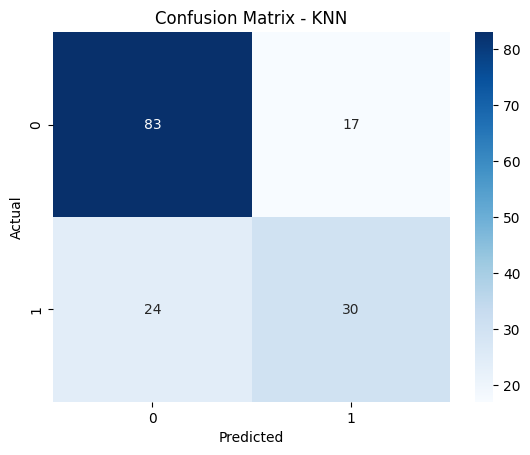


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



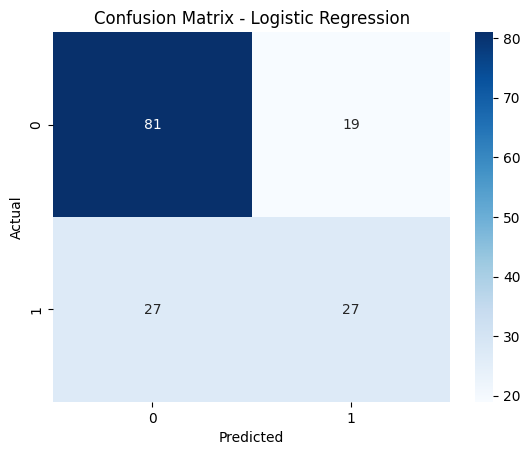


Decision Tree Results:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



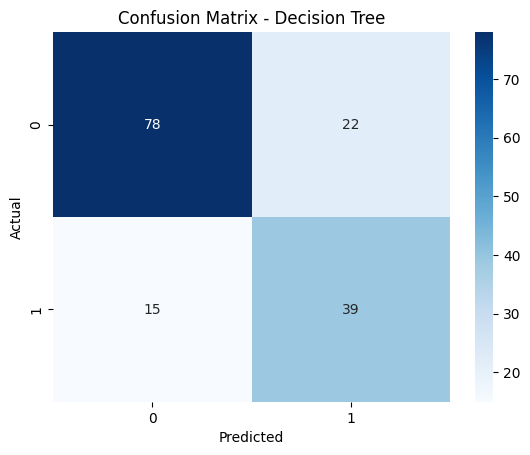

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(max_iter=1000)
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)

models = {"KNN": knn, "Logistic Regression": logreg, "Decision Tree": dtree}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



Random Forest Results:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



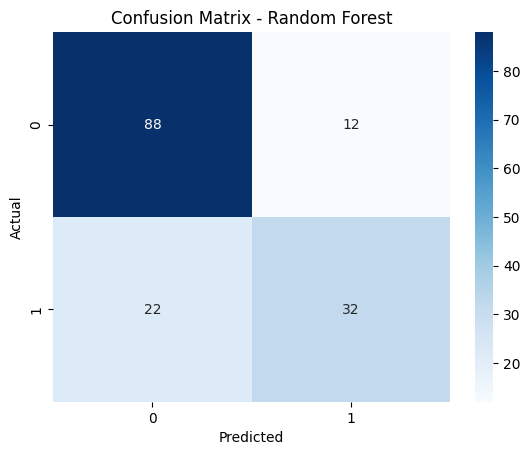

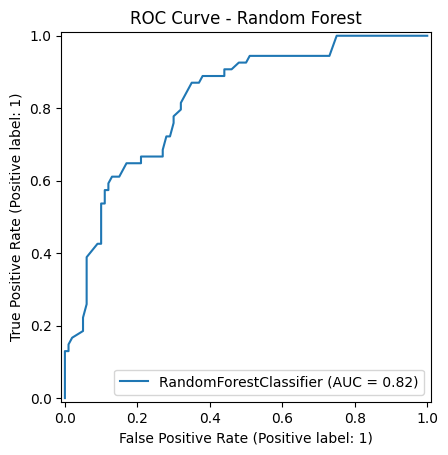


XGBoost Results:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



c:\Users\rahag\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:36:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


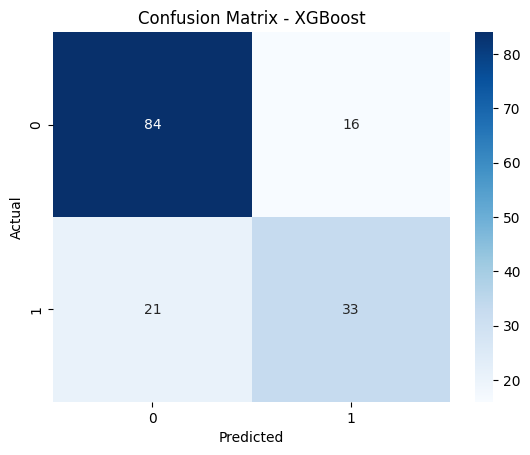

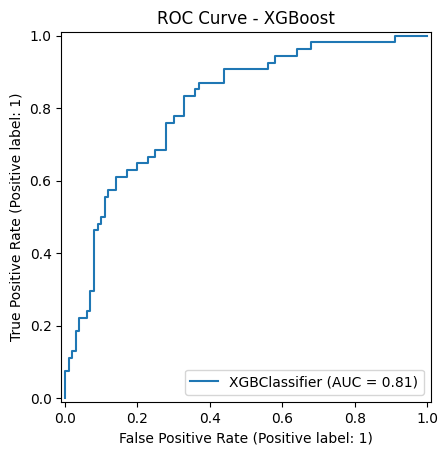


MLP Results:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



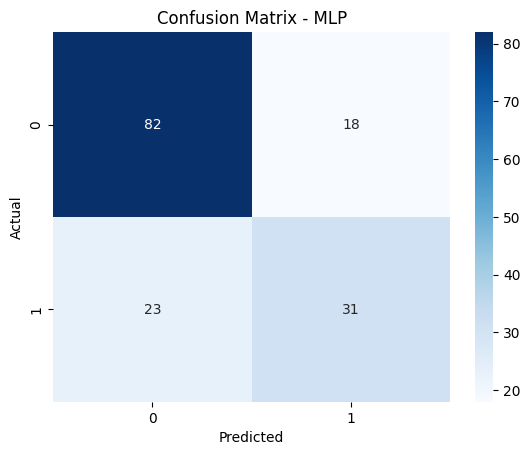

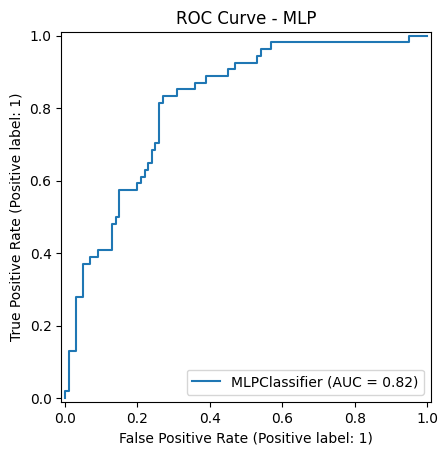

In [77]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
mlp = MLPClassifier(max_iter=500, random_state=42)

advanced_models = {"Random Forest": rf, "XGBoost": xgb, "MLP": mlp}

for name, model in advanced_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]  # for ROC
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.show()


In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_results = []

for name, model in {**models, **advanced_models}.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    all_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(all_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"])
print("\n=== Model Performance Summary ===")
print(results_df)



=== Model Performance Summary ===
                 Model  Accuracy  Precision    Recall        F1   ROC AUC
0                  KNN  0.733766   0.638298  0.555556  0.594059  0.744722
1  Logistic Regression  0.701299   0.586957  0.500000  0.540000  0.812407
2        Decision Tree  0.759740   0.639344  0.722222  0.678261  0.762222
3        Random Forest  0.779221   0.727273  0.592593  0.653061  0.818704
4              XGBoost  0.759740   0.673469  0.611111  0.640777  0.808148
5                  MLP  0.733766   0.632653  0.574074  0.601942  0.815556


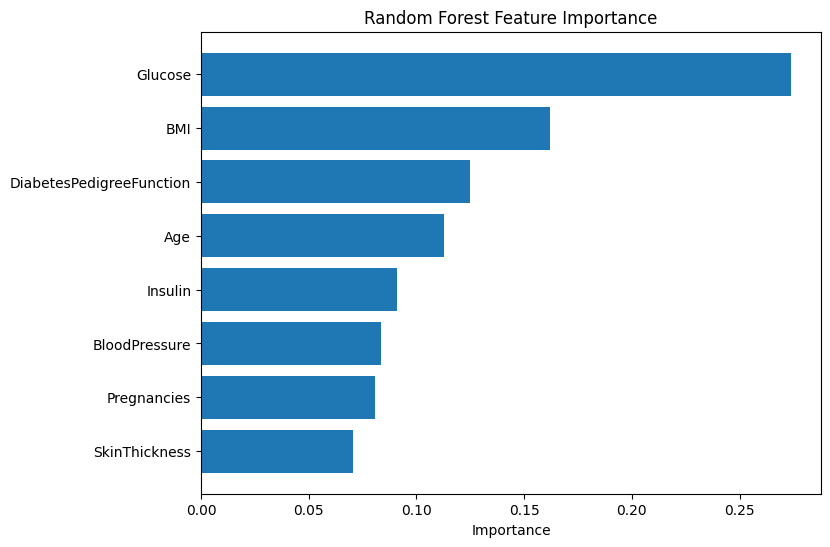

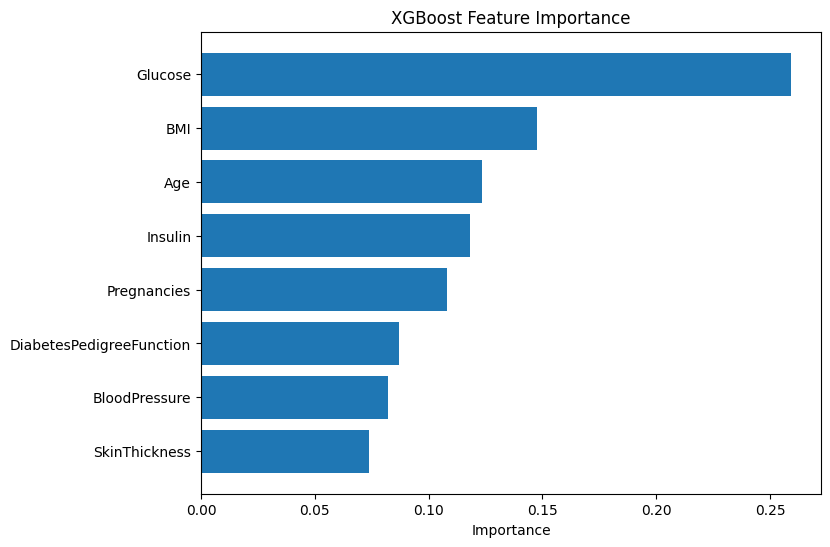

In [79]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns

rf_importances = rf.feature_importances_

plt.figure(figsize=(8,6))
indices = np.argsort(rf_importances)[::-1]
plt.barh(range(len(feature_names)), rf_importances[indices])
plt.yticks(range(len(feature_names)), feature_names[indices])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()


xgb_importances = xgb.feature_importances_

plt.figure(figsize=(8,6))
indices = np.argsort(xgb_importances)[::-1]
plt.barh(range(len(feature_names)), xgb_importances[indices])
plt.yticks(range(len(feature_names)), feature_names[indices])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()


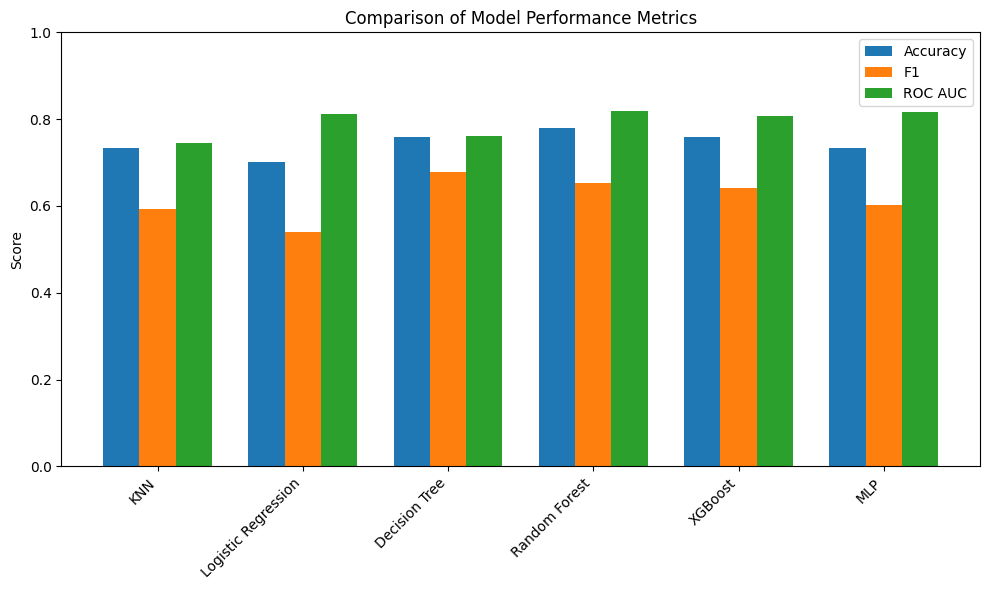

In [80]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "F1", "ROC AUC"]

x = np.arange(len(results_df["Model"])) 
width = 0.25  

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width, results_df["Model"], rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Comparison of Model Performance Metrics")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()
